# MafutaPlan: Nairobi Fuel-Price Reconstruction and Forecast Analysis

## tl;dr

This notebook is the reproducible analytical companion to the BSc IT final project. It validates 55 monthly Nairobi price cycles, audits 33 reviewed component records from 11 official EPRA Annex cycles, proves that the component identity reconstructs every recorded retail price to rounding precision, and evaluates leakage-safe next-cycle forecasting methods. The price forecast and the cost reconstruction are intentionally separate: the former is statistical; the latter is regulated arithmetic.

## Context & Methods

**Research question.** How can a source-backed information system explain, reconstruct and cautiously forecast Nairobi's regulated fuel prices without confusing landed product cost with the final pump price?

**Scope.** Nairobi only; Super Petrol (PMS), Automotive Diesel (AGO) and Kerosene (IK/DPK).

### Key assumptions

- Published EPRA values are maximum retail caps for their stated effective cycle.
- A next-cycle forecast may use only information known before that cycle.
- Stabilization is stored as a signed reconciliation adjustment because deficit/surplus signs are inconsistently displayed in scanned annexes.
- Missing or technically degraded annexes are not silently imputed as official values.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import FUEL_COLUMNS, load_component_history, load_history
from src.hybrid import AGGREGATE_COMPONENTS, reconstruction_audit
from src.modeling import forecast_fuel

pd.set_option("display.max_columns", 30)

## Data

### 1. Load the versioned research datasets

In [2]:
history = load_history()
components = load_component_history()

coverage = pd.DataFrame({
    "Dataset": ["Nairobi monthly pump prices", "Reviewed EPRA component panel"],
    "Rows": [len(history), len(components)],
    "Start": [history["Effective_From"].min(), components["Effective_From"].min()],
    "End": [history["Effective_To"].max(), components["Effective_To"].max()],
    "Grain": ["one cycle", "one cycle × fuel"],
})
coverage

,Dataset,Rows,Start,End,Grain
0,Nairobi monthly pump prices,55,2022-01-15,2026-08-14,one cycle
1,Reviewed EPRA component panel,33,2024-08-15,2026-04-14,one cycle × fuel


### 2. Run data-quality and reconstruction checks

In [3]:
audit = reconstruction_audit(components)
quality = pd.Series({
    "monthly_cycles": history["Cycle"].nunique(),
    "history_duplicates": int(history["Cycle"].duplicated().sum()),
    "component_cycles": components["Effective_From"].nunique(),
    "component_rows": len(components),
    "component_duplicates": int(components[["Effective_From", "Fuel"]].duplicated().sum()),
    "max_abs_reconstruction_error_kes": float(audit["Calculated_Error"].abs().max()),
    "official_pdf_coverage_pct": float(components["PDF_URL"].str.startswith("https://www.epra.go.ke/").mean() * 100),
}, name="Result")
quality.to_frame()

,Result
monthly_cycles,55.0
history_duplicates,0.0
component_cycles,11.0
component_rows,33.0
component_duplicates,0.0
max_abs_reconstruction_error_kes,0.0
official_pdf_coverage_pct,100.0


## Results

### 3. Reconstruct official pump prices from all cost groups

In [4]:
reconstruction_summary = (
    audit.groupby("Fuel")
    .agg(
        cycles=("Effective_From", "nunique"),
        mean_retail_price=("Retail_Price", "mean"),
        maximum_absolute_error=("Calculated_Error", lambda values: values.abs().max()),
    )
    .round(2)
)
reconstruction_summary

,cycles,mean_retail_price,maximum_absolute_error
Fuel,,,
Diesel,11,168.13,0.0
Kerosene,11,152.98,0.0
Super Petrol,11,181.00,0.0


### 4. Inspect the real landed-to-Nairobi cost mix

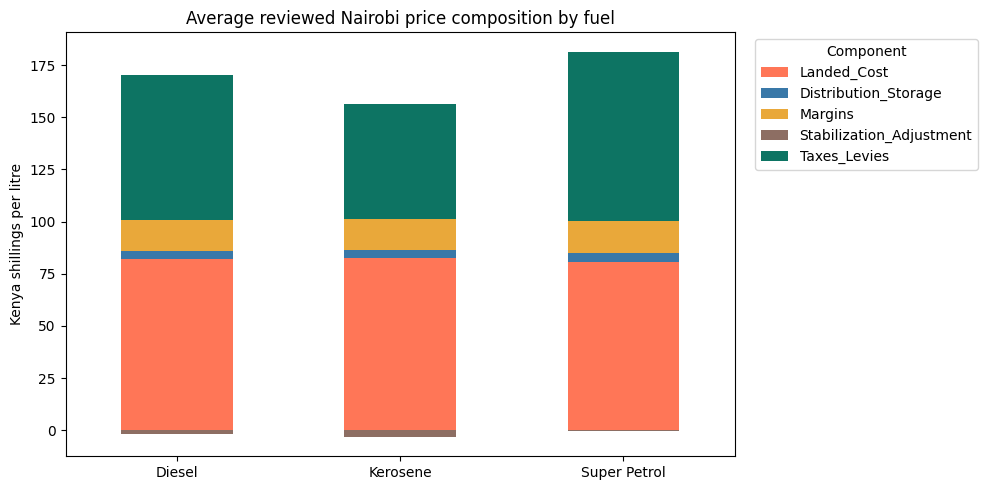

In [5]:
component_means = components.groupby("Fuel")[AGGREGATE_COMPONENTS].mean()
component_means.plot(kind="bar", stacked=True, figsize=(10, 5), color=["#ff7657", "#3978a8", "#e9a83a", "#8d6e63", "#0d7463"])
plt.title("Average reviewed Nairobi price composition by fuel")
plt.ylabel("Kenya shillings per litre")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5. Show component movement over reviewed EPRA cycles

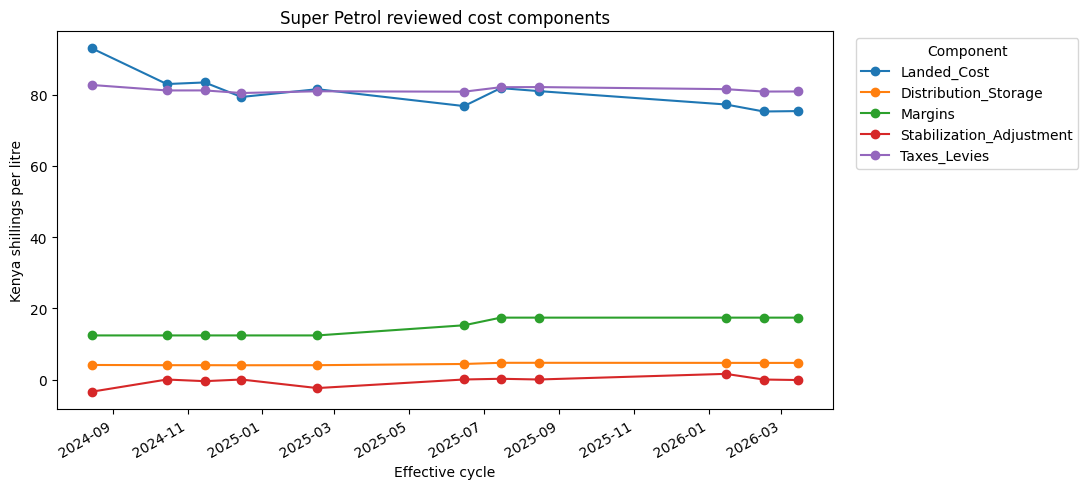

In [6]:
petrol = components.loc[components["Fuel"].eq("Super Petrol")].set_index("Effective_From")
petrol[AGGREGATE_COMPONENTS].plot(figsize=(11, 5), marker="o")
plt.title("Super Petrol reviewed cost components")
plt.ylabel("Kenya shillings per litre")
plt.xlabel("Effective cycle")
plt.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6. Evaluate leakage-safe next-cycle forecasting

In [7]:
forecast_rows = []
for fuel, column in FUEL_COLUMNS.items():
    result = forecast_fuel(history, column)
    forecast_rows.append({
        "Fuel": fuel,
        "Selected method": result.model_name,
        "Next-cycle estimate": result.prediction,
        "Holdout MAE": result.mae,
        "Holdout RMSE": result.rmse,
        "Baseline MAE": result.baseline_mae,
        "Validation cycles": result.validation_points,
    })
forecast_results = pd.DataFrame(forecast_rows).set_index("Fuel").round(2)
forecast_results

,Selected method,Next-cycle estimate,Holdout MAE,Holdout RMSE,Baseline MAE,Validation cycles
Fuel,,,,,,
Super Petrol,Previous-cycle baseline,214.03,4.24,8.20,4.24,10
Diesel,Previous-cycle baseline,222.86,8.13,15.28,8.13,10
Kerosene,Previous-cycle baseline,191.38,4.06,12.21,4.06,10


### 7. Interpret the two model layers

- **Reconstruction layer:** deterministic. It adds landed cost, Mombasa-to-Nairobi distribution/storage, regulated margins, taxes/levies and signed stabilization. Its purpose is explanation and audit.
- **Forecast layer:** statistical. Candidate regressors and tree models are compared with the previous-cycle benchmark using expanding-window selection and a final ten-cycle holdout.
- **Scenario layer:** user-controlled. It changes declared component inputs and therefore must not be described as an EPRA forecast.

The reviewed component panel is currently too short and discontinuous for a credible standalone production regression of future landed cost. That limitation is reported rather than hidden.

## Takeaways

1. The Nairobi pump price is not simply crude oil or landed product cost; inland distribution, losses, margins, taxes, levies and stabilization materially affect the final cap.
2. All 33 reviewed component records reconstruct their official retail price with a maximum absolute rounding error of KSh 0.00 per litre after signed reconciliation.
3. Regression is evaluated, but a simpler previous-cycle baseline may legitimately win when it performs better out of sample.
4. The strongest degree-project contribution is the integrated, source-backed system: acquisition audit, data validation, regulated-price reconstruction, leakage-safe forecast comparison, scenarios, calculators and a usable Streamlit interface.
5. Future work should complete a continuous 36+ cycle Annex panel, add lagged exchange-rate and international refined-product benchmarks, and re-evaluate landed-cost forecasting after the data threshold is met.